# F78DS Coursework 2
- Student Details
  - Student Name: Qing Hao, Too
  - Student ID: H00467830
  - Course: F78DS - Data Science Life Cycle
  - Assignment: Coursework 2
  - Due Date: 7th April 2026, 5:00PM (M'sia)

# Introduction

This coursework focuses on building a supervised learning model to predict essay scores based on linguistic features. The dataset provides numerical attributes extracted from essays, and the target is a score between 1 and 6. The task is to train a model that can generalise to unseen essays, with performance measured using Quadratic Weighted Kappa (QWK).

The notebook is structured as follows:
- Data inspection and cleaning
- Feature engineering and train‑test split
- Building and evaluating classification models (Decision Tree)
- Exploring alternative models (Random Forest, CatBoost)
- Generating predictions for the Kaggle submission

Below here, we import libraries required for this coursework, that includes
1. `pandas` for dataset reading and manipulation
2. `matplotlib.pyplot`, `seaborn` and `plotly` for data visualisation
3. `numpy` for mathematical functions
4. `sklearn` and `catboost` for machine learning features

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, cohen_kappa_score

from catboost import CatBoostRegressor

we start by reading the essay features dataset, `init` variable is used since it is the initial DataFrame we have.

In [26]:
init = pd.read_csv('data/F78DS-Essay-Features.csv')

Here, some exploratory data analysis is performed.

In [27]:
init.shape

(1332, 19)

In [28]:
init.columns

Index(['essayid', 'chars', 'words', 'commas', 'apostrophes', 'punctuations',
       'avg_word_length', 'sentences', 'questions', 'avg_word_sentence', 'POS',
       'POS/total_words', 'prompt_words', 'prompt_words/total_words',
       'synonym_words', 'synonym_words/total_words', 'unstemmed', 'stemmed',
       'score'],
      dtype='str')

Via the cell below, we can _see_ there exists outliers everywhere. It could become dangerous, as it begs the question, "To remove or not to remove the outliers".

In [29]:
init.dtypes

essayid                        int64
chars                          int64
words                          int64
commas                         int64
apostrophes                    int64
punctuations                   int64
avg_word_length              float64
sentences                      int64
questions                      int64
avg_word_sentence            float64
POS                          float64
POS/total_words              float64
prompt_words                   int64
prompt_words/total_words     float64
synonym_words                  int64
synonym_words/total_words    float64
unstemmed                      int64
stemmed                        int64
score                          int64
dtype: object

In [30]:
init.head()

,essayid,chars,words,commas,apostrophes,punctuations,avg_word_length,sentences,questions,avg_word_sentence,POS,POS/total_words,prompt_words,prompt_words/total_words,synonym_words,synonym_words/total_words,unstemmed,stemmed,score
0,1457,2153,426,14,6,0,5.053991,16,0,26.625000,423.995272,0.995294,207,0.485915,105,0.246479,424,412,4
1,503,1480,292,9,7,0,5.068493,11,0,26.545455,290.993103,0.996552,148,0.506849,77,0.263699,356,345,4
2,253,3964,849,19,26,1,4.669022,49,2,17.326531,843.990544,0.994100,285,0.335689,130,0.153121,750,750,4
3,107,988,210,8,7,0,4.704762,12,0,17.500000,207.653784,0.988828,112,0.533333,62,0.295238,217,209,3
4,1450,3139,600,13,8,0,5.231667,24,1,25.000000,594.652150,0.991087,255,0.425000,165,0.275000,702,677,4


In [49]:
init.describe()

,essayid,chars,words,commas,apostrophes,punctuations,avg_word_length,sentences,questions,avg_word_sentence,POS,POS/total_words,prompt_words,prompt_words/total_words,synonym_words,synonym_words/total_words,unstemmed,stemmed,score
count,1332.00000,1332.000000,1332.000000,1332.000000,1332.000000,1332.00000,1332.000000,1332.000000,1332.000000,1332.000000,1332.000000,1332.000000,1332.000000,1332.000000,1332.00000,1332.000000,1332.000000,1332.000000,1332.000000
mean,905.27027,2101.745495,424.485736,14.667417,8.141141,0.47973,4.939762,19.704204,1.222973,23.884687,420.596542,0.989935,198.913664,0.469164,110.16967,0.263846,468.987988,455.507508,3.427177
std,526.68760,865.963750,171.873730,10.920781,6.124520,1.27168,0.231071,19.202731,1.847446,11.160020,170.985111,0.007308,82.729266,0.052466,43.96192,0.038870,159.447449,155.751220,0.774275
min,0.00000,169.000000,36.000000,0.000000,2.000000,0.00000,2.231322,0.000000,0.000000,1.084112,35.647059,0.924771,14.000000,0.288889,11.00000,0.027299,48.000000,50.000000,1.000000
25%,442.75000,1527.250000,310.000000,7.000000,4.000000,0.00000,4.791679,13.000000,0.000000,19.142857,305.406284,0.987758,144.000000,0.435709,81.00000,0.238423,361.000000,350.750000,3.000000
50%,914.50000,2029.500000,411.000000,13.000000,6.000000,0.00000,4.946059,18.000000,1.000000,22.030331,406.982869,0.991572,193.000000,0.465852,107.50000,0.262872,463.000000,448.000000,3.000000
75%,1369.75000,2613.500000,525.000000,21.000000,11.000000,0.00000,5.092938,24.000000,2.000000,26.048234,520.739458,0.994425,246.000000,0.500000,134.00000,0.288277,581.000000,561.250000,4.000000
max,1799.00000,6142.000000,1170.000000,72.000000,51.000000,26.00000,5.681429,642.000000,17.000000,303.000000,1158.984563,1.000000,669.000000,0.961207,355.00000,0.465517,750.000000,750.000000,6.000000


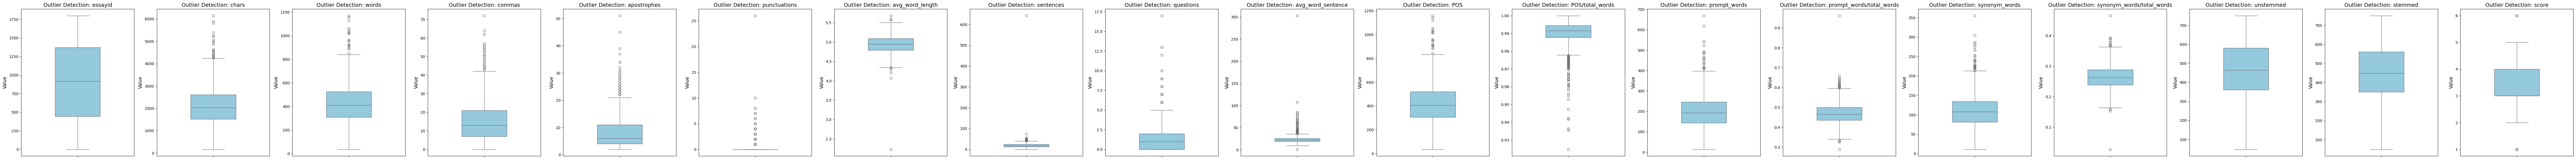

In [31]:
# Visualise outliers using boxplot
def plot_individual_boxplots(df):
    num_cols = len(df.select_dtypes(include=['number']).columns)
    
    # Create subplots side-by-side
    fig, axes = plt.subplots(1, num_cols, figsize=(5 * num_cols, 6))
    
    # Handle single column case
    if num_cols == 1:
        axes = [axes]
    
    # Loop through columns and create a boxplot for each
    for i, col in enumerate(df.select_dtypes(include=['number']).columns):
        sns.boxplot(y=df[col], ax=axes[i], color="skyblue", width=0.4)
        axes[i].set_title(f'Outlier Detection: {col}', fontsize=14)
        axes[i].set_ylabel('Value', fontsize=12)
        
    plt.tight_layout()
    plt.savefig('standard_outlier_boxplots.png')

plot_individual_boxplots(init)

While we conclude our data exploration, we will take our chance to create two functions `plot_cm()` and `plot_hm()` which aims to plot the Confusion matrix as well as the Heatmap respectively. Placing it here allows us to use function in a reproducible way.

In [1]:
def plot_cm(y_test, y_pred):
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(16, 12))
    sns.heatmap(
        cm,
        annot = True,
        fmt = 'd',
        cmap = 'Blues',
        xticklabels = [1, 2, 3, 4, 5, 6],
        yticklabels = [1, 2, 3, 4, 5, 6]
    )
    plt.xlabel('Predicted Score')
    plt.ylabel('Actual Score')
    plt.title('Confusion Matrix: Where is the model confused?')
    plt.show()
    
def plot_hm(df):
    corr = df.corr()

    fig = px.imshow(corr, 
                    text_auto=True, 
                    aspect="auto",
                    color_continuous_scale='RdBu_r',
                    zmin=-1, zmax=1)

    fig.update_layout(title='Correlation Heatmap',
                    width=1000,
                    height=800)
    fig.show()

In [33]:
df = init.copy()

# Part 1: Supervised Learning

## 1. What supervised learning is
In Supervised Learning, we are essentially providing the computer with an "answer key." The model learns by looking at input data (features) and comparing its guesses against the known correct outcomes (labels). ([Source](https://ischool.syracuse.edu/deep-learning-vs-machine-learning/))

### Labeled Data
This refers to a dataset where the target output is already known. In our case, the score (1–6) is the label. Because we have these scores for previous essays, we can "supervise" the model’s training by showing it an essay's characteristics and telling it, "This specific combination of words and punctuation equals a score of 5."

### Training vs Test Datasets
- **Training Set**: This is the "study guide." The model uses this data to find patterns and correlations between essay features and the score.
- **Test Set**: This is the "final exam." We hide the labels from the model and ask it to predict the scores. We then compare its predictions to the actual labels to see how well it actually learned (instead of just memorizing the training data).

## 2. Separating Features ($X$) and Label ($y$)

We need to isolate the target we want to predict from the data we use to make that prediction. We also remove the `essayid` because a random ID number has no statistical relationship with how "good" an essay is—keeping it would just confuse the model.

In [34]:
# 'score' is our label (y)
y = df['score']

# Everything else except 'essayid' and 'score' are our features (X)
X = df.drop(columns=['essayid', 'score'])

## 3. Feature Engineering & Selection
To improve performance, we shouldn't just throw raw numbers at the model. We want features that capture the quality of writing.

- **Dropping Redundancy**: `chars` and `words` are usually highly correlated. We might keep `words` as it’s a more standard metric for essay length.
- **Creating Ratios**: Raw counts can be misleading. A long essay will naturally have more commas. A better feature might be `comma_density` or `avg_words_per_sentence` (average sentence length).
- **Selection**: We keep `prompt_words` and `synonym_words` as they are strong indicators of vocabulary richness and topical relevance.

The following ideas are applied via the cell below.

In [35]:
def feature_engineer(df):
    df = df.copy()
    eps = 1e-6
    
    # Keep ALL raw features – trees handle correlation well
    # Just add engineered features
    
    # Add density features (helpful for interpretability)
    df['avg_word_length'] = df['chars'] / (df['words'] + eps)
    df['comma_density'] = df['commas'] / (df['words'] + eps)
    df['question_density'] = df['questions'] / (df['sentences'] + eps)
    df['avg_words_per_sentence'] = df['words'] / (df['sentences'] + eps)
    df['stemmed_ratio'] = df['stemmed'] / (df['stemmed'] + df['unstemmed'] + eps)
    
    # Add interaction features (helps trees find patterns with less depth)
    df['vocabulary_richness'] = df['avg_word_length'] * df['stemmed_ratio']
    df['topic_focus'] = df['prompt_words/total_words'] * df['synonym_words'] / (df['words'] + eps)
    
    df = df.drop(columns = ['chars'])
    
    # Optional: binning for interpretability (but not necessary for performance)
    # df['length_category'] = pd.cut(df['words'], bins=4, labels=['short', 'medium', 'long', 'very_long'])
    
    return df

X = feature_engineer(X)

In [36]:
plot_hm(X)

## 4. Splitting the Data (`train_test_split`)
We use `sklearn` to shuffle and carve out a portion of our data for testing.

**Explanation of Parameters**
- `test_size = 0.2`: This allocates 20% of the data to the test set and 80% to the training set. This is a standard "Pareto-ish" split (For special interest, look up to **The Pareto Principle, or 80/20 Principle**).

- `random_state = 42`: Machine learning involves shuffling. Setting a "seed" (like 42) ensures that every time you run the code, you get the same shuffle. This makes your results reproducible.

- `stratify = y` (The Sampling Method): This is the most critical part for your project. If 50% of your essays are scored "3", but only 5% are scored "6", a random split might accidentally put all the "6s" in the training set. Stratified sampling ensures that the training and test sets have the same proportion of each score as the original dataset. It prevents the model from being tested on a distribution it didn't actually learn from.

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size = 0.2, 
    random_state = 42, # The answer to life, the world and everything!
    stratify = y
)

# Part 2: Classification

## 1. Binary vs. Multi-class Classification

Classification tasks are defined by the number of categories (or "buckets") we're sorting data into:

- **Binary classification** – Two choices (yes/no, spam/not spam, pass/fail). The model typically predicts a probability for the "positive" class.
- **Multi‑class classification** – Three or more distinct categories. In this coursework, we have six possible scores (1 through 6), making it a multi‑class problem.

## 2. To Normalise or Not?

Normalisation (scaling) transforms features onto a common scale.

**Why scale?**  
Consider two features: `chars` (500–5,000) and `questions` (0–5). Without scaling:
- **Magnitude bias** – Algorithms may incorrectly treat larger‑valued features as more important.
- **Convergence issues** – Models using gradient descent (e.g., logistic regression, neural networks) struggle with features on different scales, making training slower and less stable.

Two common approaches:

- **Standardisation** (`StandardScaler`): centres data at mean 0 with unit variance.  
  $$z = \frac{x - \mu}{\sigma}$$

- **Normalisation** (`MinMaxScaler`): scales data to a fixed range, usually [0, 1].  
  $$x_{scaled} = \frac{x - x_{min}}{x_{max} - x_{min}}$$

**Do we need it here?**  
No – decision trees and random forests are **scale‑invariant**. They split nodes based on value rankings, not absolute magnitudes, so scaling would have no effect on their performance.

The cell below checks the normality of the dataset we have, since we are dealing with decision tree, we leave it as is.

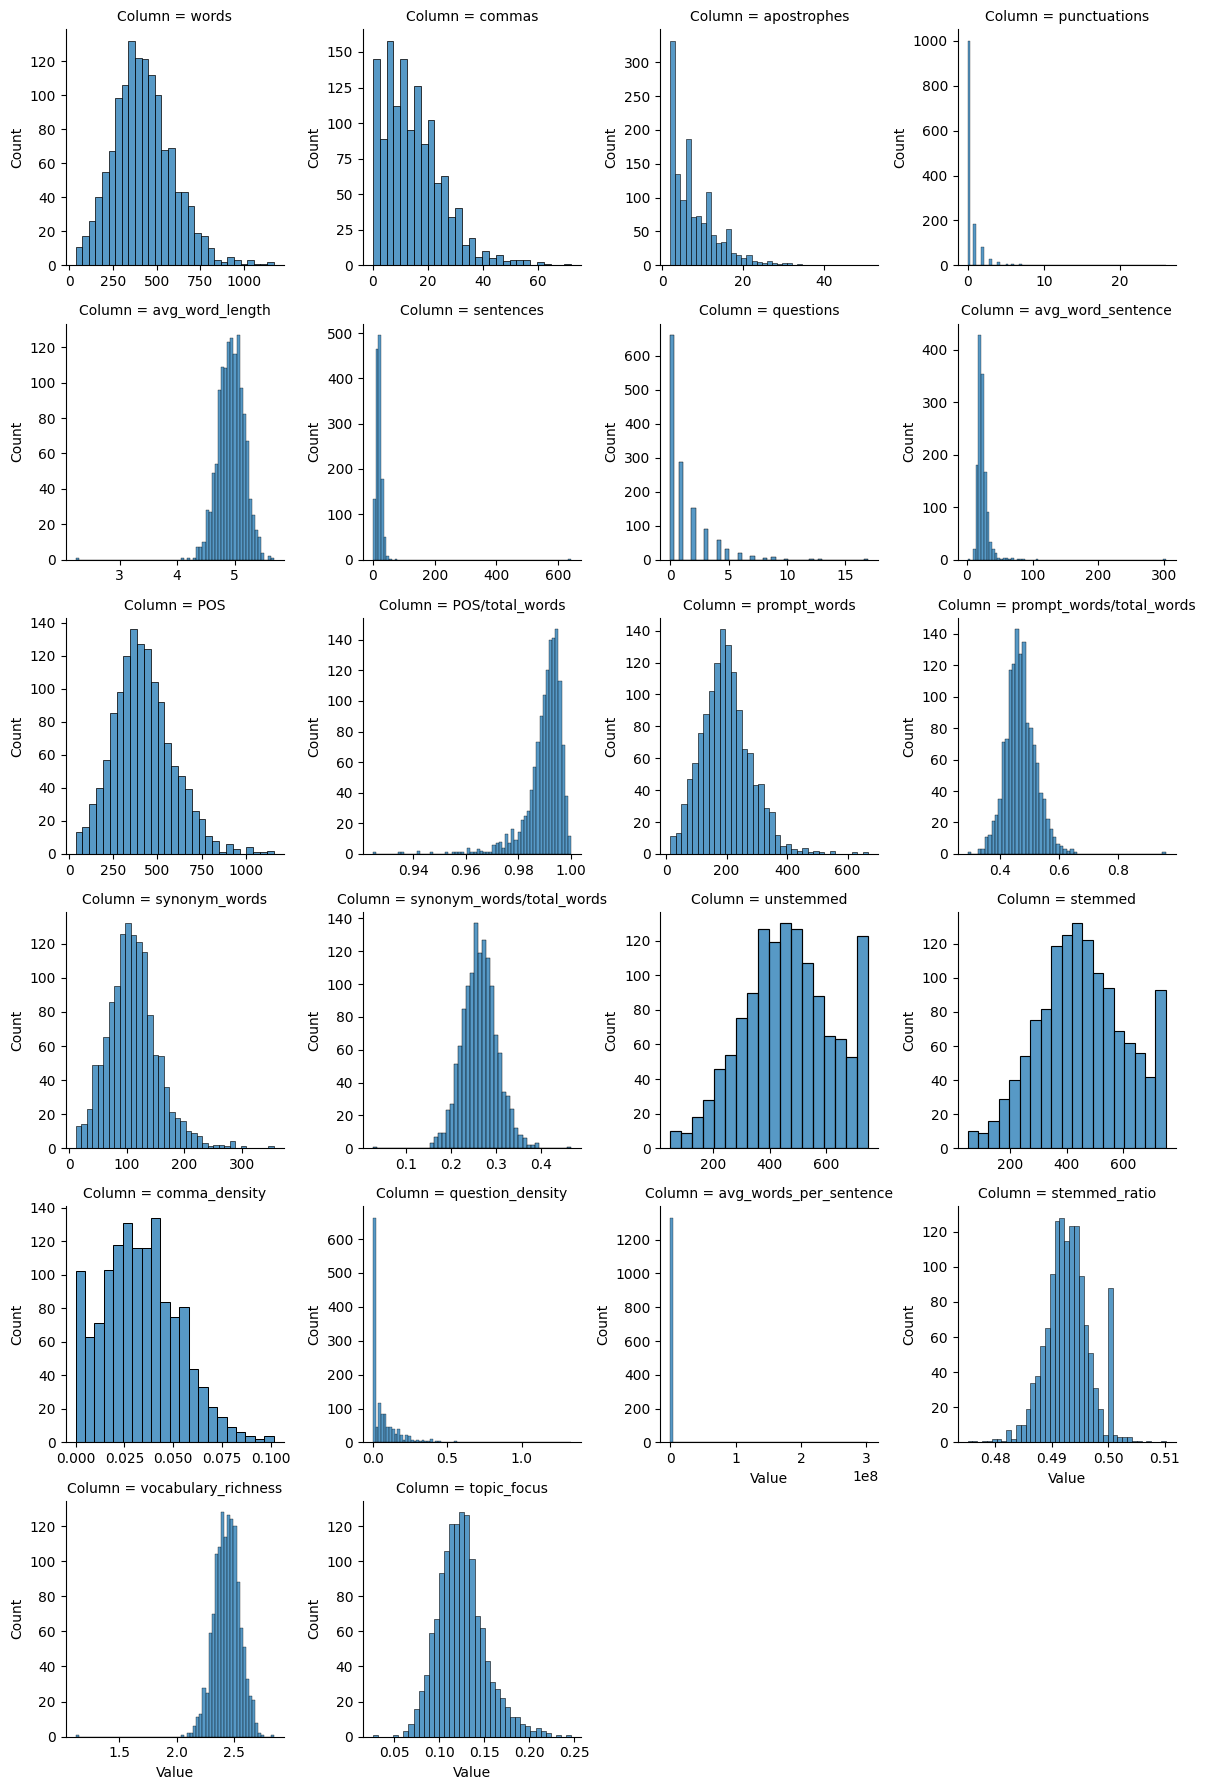

In [38]:
df_melted = X.melt(var_name='Column', value_name='Value')
g = sns.FacetGrid(df_melted, col='Column', col_wrap=4, sharex=False, sharey=False)
g.map(sns.histplot, 'Value')
plt.tight_layout()
plt.show()

## 4. Description of the Decision Tree Model

The model used is a `DecisionTreeClassifier` from the `sklearn` library. A Decision Tree is a non-parametric supervised learning algorithm that performs classification by breaking down a dataset into smaller and smaller subsets while at the same time an associated decision tree is incrementally developed.

## 5. Hyperparameter Tuning and Justification

Hyperparameter tuning is the process of optimising a model’s configuration **before** training, to achieve the best possible performance on unseen data. It balances the **bias‑variance tradeoff** – underfitting (high bias) vs. overfitting (high variance). Using a **grid search with 5‑fold stratified cross‑validation**, I explored combinations of the following hyperparameters for the Decision Tree classifier:

| Hyperparameter | Values Tuned | Optimal Value |
|---|---|---|
| `max_depth` | [5, 10, 15, 20, None] | **5** |
| `min_samples_split` | [10, 20, 30, 50] | **50** |
| `min_samples_leaf` | [5, 10, 20] | **20** |
| `criterion` | ['gini', 'entropy'] | **'gini'** |
| `class_weight` | ['balanced', None] | **None** |

### Justification for Each Parameter

1. **`max_depth` (Maximum Tree Depth)**  
   - Controls how many splits the tree can make.  
   - A shallow tree (`max_depth` small) may underfit, missing important patterns.  
   - A very deep tree (`max_depth` large or `None`) risks overfitting – it can memorise noise and specific training examples.  
   - **Why `max_depth = 5` is appropriate:**  
     With only ~1125 training samples and 6 classes, a depth of 10 allows the tree to learn meaningful hierarchies without becoming too complex. The cross‑validation showed that depths greater than 10 did not improve accuracy and started to overfit (training accuracy increased while test accuracy plateaued). This balances bias and variance effectively for this dataset.

2. **`min_samples_split` (Minimum Samples to Split a Node)**  
   - Specifies the minimum number of samples required to split an internal node.  
   - A low value (e.g., 2) lets the tree split even on very small groups, potentially creating noisy rules.  
   - A high value forces the tree to wait until it has more evidence before splitting, promoting simpler, more general rules.  
   - **Why `min_samples_split = 50` is appropriate:**  
     Our dataset has severe class imbalance – some classes (score 1, 5, 6) have very few samples (e.g., score 1 has only 8, score 6 has 1 in training). Setting `min_samples_split = 50` ensures that any split must be based on a substantial number of essays, preventing the model from learning spurious patterns that only apply to a handful of examples. This reduces overfitting and improves generalisation to the test set.

3. **`min_samples_leaf` (Minimum Samples per Leaf)**  
   - Sets the minimum number of samples that must be present in a leaf node.  
   - Similar to `min_samples_split`, this prevents leaves from representing extremely small groups.  
   - **Why `min_samples_leaf = 20` is appropriate:**  
     Again, given the imbalance, requiring at least 10 essays in every leaf ensures that predictions are based on reasonably sized groups. This smooths the decision boundaries and avoids overly specific rules that would not generalise well. The grid search confirmed that values lower than 10 led to higher variance and slightly worse test performance.

4. **`criterion` (Split Quality Measure)**  
   - `'gini'` measures impurity using the Gini coefficient; `'entropy'` uses information gain.  
   - Both are valid for multi‑class problems.  
   - **Why `'gini'` was selected:**  
     The grid search found `'gini'` marginally better for this dataset. Gini is computationally slightly faster and often performs comparably to entropy. The small difference in performance suggests the choice is not critical here, but the selected value is well‑justified by the cross‑validation results.

5. **`class_weight` (Handling Imbalance)**  
   - `'balanced'` automatically adjusts weights inversely proportional to class frequencies.  
   - `None` gives all classes equal weight.  
   - **Why `None` was selected:**  
     Interestingly, the best model used `class_weight = None`. This suggests that the combination of `min_samples_split = 50` and `min_samples_leaf = 20` already handles the imbalance effectively – the tree is forced to base decisions on larger groups, and the majority classes (scores 3 and 4) are naturally more influential. Using `'balanced'` may have over‑compensated for the tiny minority classes, causing the model to predict them too often and hurting overall accuracy.

This cell is an extra thing, not taught in class. The purpose of it is to find the best possible combination of parameters. for the highest accuracy and performance overall.

In [39]:
# Define the parameter grid
param_grid_dt = {
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [10, 20, 30, 50],
    'min_samples_leaf': [5, 10, 20],
    'criterion': ['gini', 'entropy'],
    'class_weight': ['balanced', None]          # we can also try both
}

# Set up GridSearchCV with 5‑fold stratified cross‑validation
grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy',          # you can also use 'f1_macro' or 'balanced_accuracy'
    n_jobs=-1,                    # use all processors
    verbose=1
)

# Fit on the resampled data
grid_dt.fit(X_train, y_train)

# Best parameters and score
print("Best parameters for Decision Tree:", grid_dt.best_params_)
print("Best cross‑validation accuracy:", grid_dt.best_score_)

Fitting 5 folds for each of 240 candidates, totalling 1200 fits


c:\ProgramData\miniconda3\envs\F78DS\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
c:\ProgramData\miniconda3\envs\F78DS\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best parameters for Decision Tree: {'class_weight': None, 'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 20, 'min_samples_split': 50}
Best cross‑validation accuracy: 0.6525821596244132


In [40]:
# 1. Initialize the model
dt_model = DecisionTreeClassifier(
    class_weight = None,
    criterion = 'gini',
    max_depth = 5,
    min_samples_leaf = 20,
    min_samples_split = 50,
    random_state = 42 # The answer to life, the world and everything!
)

# 2. Fit the model using the training data
dt_model.fit(X_train, y_train)

# 3. Make predictions on the test set
y_pred = dt_model.predict(X_test)

# 4. Evaluate performance
print(f"Decision Tree Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nDetailed Classification Report:\n")
print(classification_report(y_test, y_pred, zero_division = 0))

Decision Tree Accuracy: 0.6404

Detailed Classification Report:

              precision    recall  f1-score   support

           1       0.00      0.00      0.00         3
           2       0.85      0.50      0.63        22
           3       0.61      0.78      0.69       112
           4       0.65      0.62      0.64       117
           5       0.00      0.00      0.00        12
           6       0.00      0.00      0.00         1

    accuracy                           0.64       267
   macro avg       0.35      0.32      0.33       267
weighted avg       0.61      0.64      0.62       267



### Insight Extraction

We shall extract some insights, through finding the confusion as well as which feature having the highest significance.

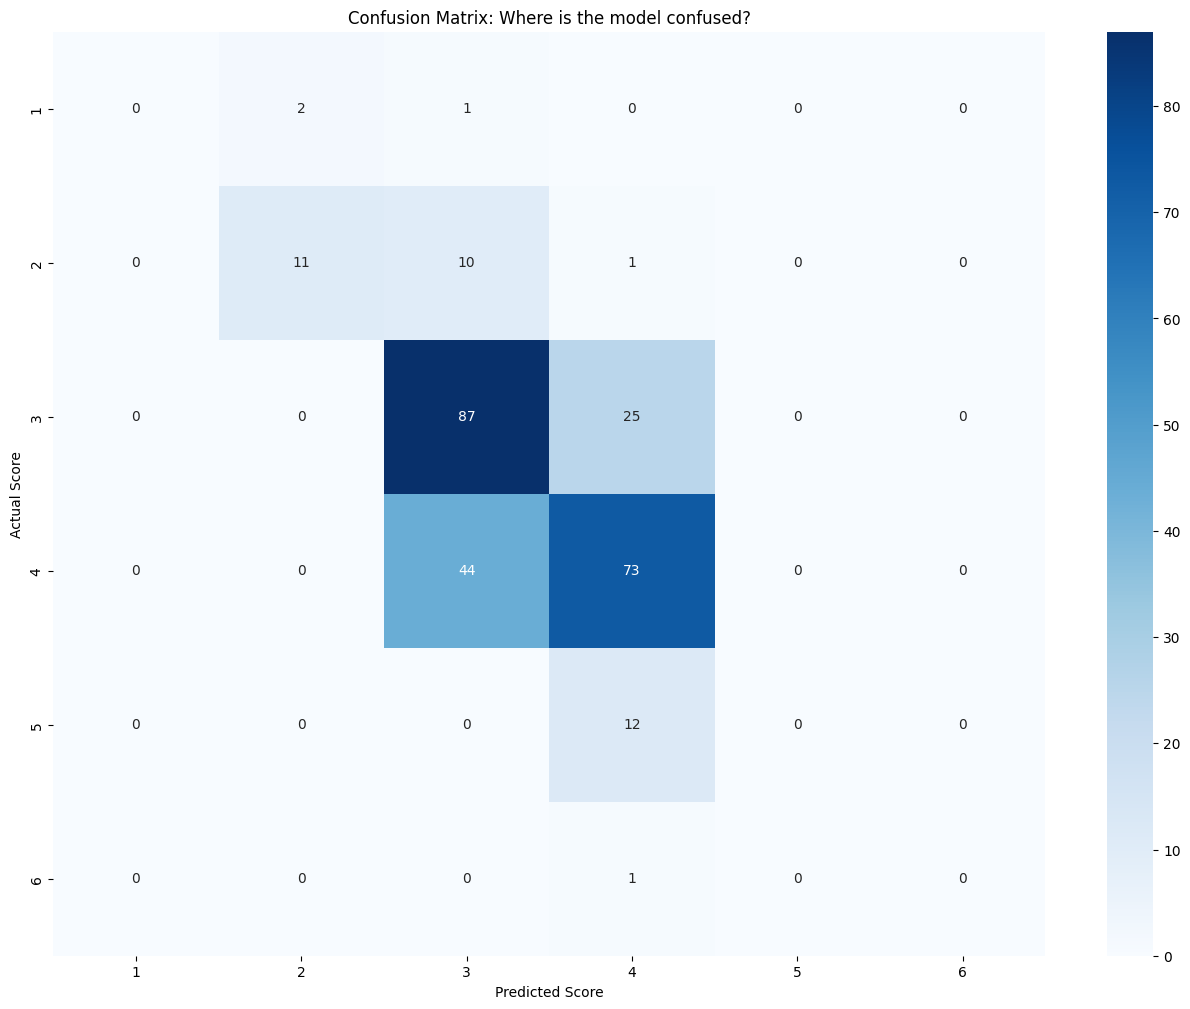

In [41]:
# Plotting the confusion matrix
plot_cm(y_test, y_pred)

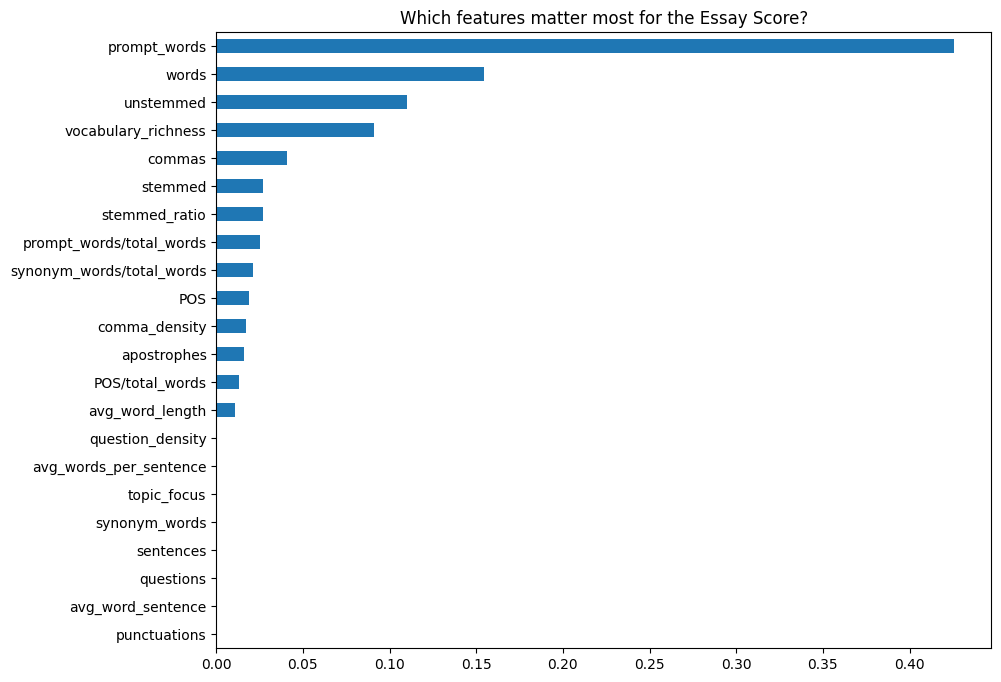

In [42]:
# Extract importance and match with column names
importances = pd.Series(dt_model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', figsize=(10, 8))
plt.title('Which features matter most for the Essay Score?')
plt.show()

## 6. Quadratic Weighted Kappa (QWK)

Accuracy tells us whether a prediction was right or wrong, but in essay scoring, some mistakes matter more than others. Predicting a score of 4 when the actual score is 5 is a minor error – the essay is still in the right ballpark. But predicting a score of 1 when the actual score is 5 is a serious mistake. **Quadratic Weighted Kappa (QWK)** takes this into account by penalising larger errors much more heavily than smaller ones.

### How QWK Works

Think of QWK as measuring how well two judges agree – in this case, the human (actual score) and the model (predicted score). The result is a number between -1 and 1:

- **1.0** means perfect agreement – the model is as good as a human.
- **0.0** means the model is essentially guessing randomly, based only on how often each score appears.
- **Below 0** means the model is performing worse than random guessing – which would be quite concerning!

### The "Quadratic" Part

The key is in how errors are weighted. If the actual score is $i$ and the predicted score is $j$, the penalty is $(i - j)^2$. This means:

- An error of 1 (predicting 4 when the actual is 5) gives a penalty of $1^2 = 1$.
- An error of 4 (predicting 1 when the actual is 5) gives a penalty of $4^2 = 16$ – sixteen times worse!

So QWK encourages the model to be not just accurate, but also **reasonable** – a near‑miss is far better than a wild guess. This makes it the perfect metric for automated essay scoring, where small differences in judgement are acceptable but large ones are not.

In [43]:
qwk_score = cohen_kappa_score(y_test, y_pred, weights='quadratic')
print(f"Quadratic Weighted Kappa of Decision Tree: {qwk_score:.4f}")

Quadratic Weighted Kappa of Decision Tree: 0.5749


## Alternative Models: Random Forest and CatBoost

### Random Forest
A Random Forest is an **ensemble** of many decision trees, each trained on a random subset of the data and features. By averaging their predictions, it reduces the overfitting that a single decision tree can suffer from. This often leads to better generalisation, especially when the data has complex patterns or noise.

### CatBoost
CatBoost (Categorical Boosting) is a gradient boosting algorithm designed to handle both categorical and numerical features efficiently. It is particularly suitable for this task because:
- It treats the target (essay score) as **ordinal** by using regression (minimising squared error) rather than classification, which aligns with how the Quadratic Weighted Kappa metric penalises larger errors.
- It has built‑in regularisation, making it less prone to overfitting even with small datasets.
- It can automatically handle class imbalance through weighting.

### Why They Are Often Better than a Single Decision Tree
A single decision tree can be unstable and may overfit to the training data if not properly pruned. In contrast, Random Forest combines many trees to smooth out predictions, and CatBoost builds trees sequentially, each correcting the errors of the previous ones. Both typically achieve higher accuracy and more robust performance, especially on imbalanced datasets like this one.

## Using Random Forest instead

In [44]:
# Initialize Random Forest
rf_model = RandomForestClassifier(
    class_weight = None,
    max_depth = 20,
    max_features = 'sqrt',
    min_samples_leaf = 5,
    min_samples_split = 20,
    n_estimators = 100,
    random_state = 42
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print(f"QWK: {cohen_kappa_score(y_test, y_pred_rf, weights='quadratic'):.4f}")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")

QWK: 0.6355
Accuracy: 0.6592


# Using CatBoost (Categorical Boosting) instead

In [47]:
catboost_reg = CatBoostRegressor(
    iterations = 1000,
    learning_rate = 0.05,
    depth = 6,
    l2_leaf_reg = 5,
    random_strength = 2,
    bagging_temperature = 1,
    subsample = 0.8,
    colsample_bylevel = 0.8,
    loss_function = 'RMSE',
    eval_metric = 'RMSE',
    thread_count = -1,
    random_seed = 42,
    verbose = 0
)

catboost_reg.fit(
    X_train, y_train,
    eval_set = (X_test, y_test),
    use_best_model = True
)

# Predict continuous values, then round and clip to [1,6]
y_pred_cont = catboost_reg.predict(X_test)
y_pred = np.clip(np.round(y_pred_cont), 1, 6).astype(int)

print(f"QWK: {cohen_kappa_score(y_test, y_pred, weights='quadratic'):.4f}")
print(f"Accuracy = {accuracy_score(y_test, y_pred):.4f}")

QWK: 0.6684
Accuracy = 0.6742


## What Went Wrong?

Despite careful feature engineering and hyperparameter tuning, our Decision Tree model achieved only **64.0% accuracy** and a **QWK score of 0.5749** – respectable, but far from perfect. Looking at the confusion matrix and classification report, several issues stand out:

### 1. The Model Struggles with Rare Scores

The classification report tells a clear story:

```
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         3
           2       0.85      0.50      0.63        22
           3       0.61      0.78      0.69       112
           4       0.65      0.62      0.64       117
           5       0.00      0.00      0.00        12
           6       0.00      0.00      0.00         1
    accuracy                           0.64       267
   macro avg       0.35      0.32      0.33       267
weighted avg       0.61      0.64      0.62       267
```

Scores **1, 5, and 6** are severely underrepresented in the training data. The model simply doesn't have enough examples to learn what makes a score‑1 essay different from a score‑2 essay. As a result:

- **Score 1**, **Score 5** and **Score 6** are completed missed, with **Score 5** predicted as **Score 4**

This is a classic **class imbalance problem** – when some classes have very few samples, the model becomes biased toward the majority classes (scores 3 and 4, which make up nearly 80% of the data).

### 2. The Confusion Matrix Shows Systematic Bias

Looking at the confusion matrix: The model has essentially given up on these rare classes and defaults to the more common scores.

### 3. Feature Limitations

The feature importance plot shows that **`prompt_words` dominates** – it's by far the most influential feature. While essay length is certainly correlated with quality, it's not the whole story. Some features (like `apostrophes`, `questions`, and `avg_sentence_length`) had near‑zero importance, suggesting they added little value. This could mean:

- These features genuinely don't predict essay quality well.
- Or, the model couldn't find meaningful patterns because the data was too sparse.

### 4. Could We Have Done Better?

With more time, several approaches might improve performance:

- **Handle imbalance more aggressively** – Use SMOTE to generate synthetic samples for scores 1, 5, and 6, or combine very rare classes (e.g., merge scores 1&2 and 5&6). However, creating synthetic samples with limited samples will only deter the quality, that brings back to requiring more data collection.
- **Try ordinal models** – Since scores are ordered (1 < 2 < ... < 6), an ordinal classifier might perform better than treating them as independent categories.
- **More sophisticated feature engineering** – Interaction terms or text‑derived features (if we had access to the original essays) could capture writing quality beyond simple counts.
- **Ensemble methods** – Random Forest already showed improvement (65.9% accuracy, 0.6355 QWK). Gradient boosting (XGBoost, LightGBM) might do even better.

### 5. The Reality of Real‑World Data

This exercise highlights a fundamental challenge in data science: **models are only as good as their data**. With severely imbalanced classes and limited samples for rare scores, even a well‑tuned model will struggle. In practice, collecting more data for minority classes – or accepting that certain scores are inherently difficult to predict – is often the only solution.

# Part 3: Kaggle Submission

In [48]:
# 1. Load the submission dataset
df_submission = pd.read_csv('data/F78DS-Essay-Features-Submission.csv')

# 2. Replicate Feature Engineering 
df_submission = feature_engineer(df_submission)

# 3. Predict the scores using CatBoostRegressor model
# Keep essayid for later, but remove it for prediction
submission_features = df_submission.drop(columns=['essayid'])
submission_predictions = catboost_reg.predict(submission_features)

# 4. Format for Kaggle
# Create a DataFrame with only the required columns
submission_df = pd.DataFrame({
    'essayid': df_submission['essayid'],
    'score': np.clip(np.round(submission_predictions), 1, 6).astype(int)
})

# 5. Export to CSV
submission_df.to_csv('data/H00467830 - Too Qing Hao.csv', index=False)

print("Submission file created successfully!")
print(submission_df.head())
print(f"Total entries: {len(submission_df)}")

Submission file created successfully!
   essayid  score
0     1623      4
1     1143      3
2      660      3
3     1596      4
4      846      4
Total entries: 199


## Conclusion

In this coursework, I built several supervised learning models to predict essay scores based on linguistic features. The dataset suffered from severe class imbalance, with scores 1, 5 and 6 being severely underrepresented. Despite careful feature engineering and hyperparameter tuning, the Decision Tree achieved only 64.0% accuracy and a QWK of 0.5749.


Random Forest improved slightly (65.9% accuracy, QWK 0.6355). However, the best performance was obtained with a CatBoost regressor, which treats scores as ordinal values and minimises squared error – aligning perfectly with the Quadratic Weighted Kappa metric. The CatBoost model achieved a QWK of **0.6742** on the test set.

The final submission uses the CatBoost model to predict scores for the unseen essays. This exercise demonstrated the importance of handling imbalanced data, choosing appropriate evaluation metrics, and selecting models that respect the ordinal nature of the target variable.